# 1-dimensional

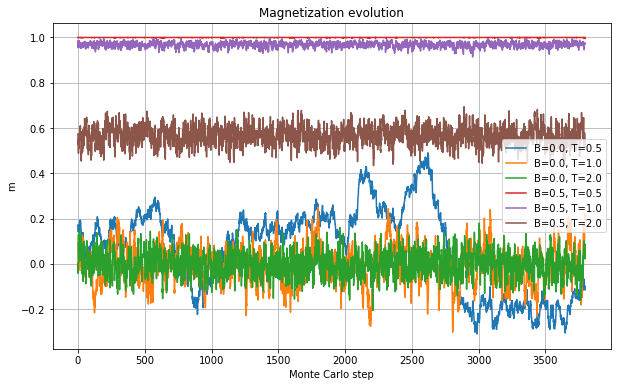

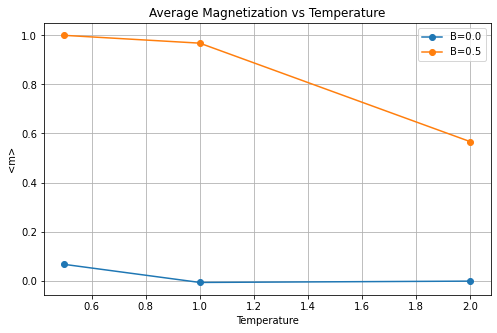

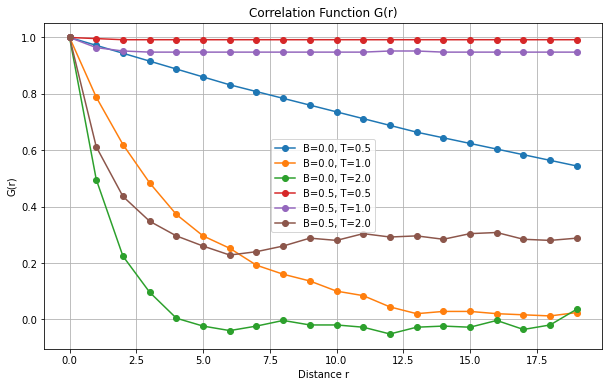

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# =============================
# Metropolis Algorithm for 1D Ising Model
# =============================

class Ising1D:
    def __init__(self, N=100, J=1.0, B=0.0, T=1.0):
        self.N = N
        self.J = J
        self.B = B
        self.T = T
        self.beta = 1.0 / T
        self.spins = np.random.choice([-1, 1], size=N)

    def energy(self):
        """Compute total energy"""
        E = 0
        for i in range(self.N):
            E -= self.J * self.spins[i] * self.spins[(i+1) % self.N]
            E -= self.B * self.spins[i]
        return E

    def magnetization(self):
        """Compute magnetization per spin"""
        return np.mean(self.spins)

    def metropolis_step(self):
        """Single Metropolis update"""
        for _ in range(self.N):
            i = np.random.randint(0, self.N)
            s = self.spins[i]
            neighbors = self.spins[(i-1) % self.N] + self.spins[(i+1) % self.N]

            dE = 2 * self.J * s * neighbors + 2 * self.B * s

            if dE < 0 or np.random.rand() < np.exp(-self.beta * dE):
                self.spins[i] *= -1

    def run(self, steps=1000, thermalization=200):
        """Run simulation and collect observables"""
        mags = []
        energies = []

        for step in range(steps):
            self.metropolis_step()

            if step > thermalization:
                mags.append(self.magnetization())
                energies.append(self.energy() / self.N)

        return np.array(mags), np.array(energies)

    def correlation_function(self, max_r=20):
        """Compute spatial correlation function"""
        G = []
        for r in range(max_r):
            corr = np.mean(self.spins * np.roll(self.spins, -r))
            G.append(corr)
        return np.array(G)

# =============================
# Simulation parameters
# =============================
N = 1000
steps = 4000

# Temperature cases (no real Tc in 1D, but illustrative)
temps = [0.5, 1.0, 2.0]
B_values = [0.0, 0.5]

results = {}

for B in B_values:
    for T in temps:
        model = Ising1D(N=N, J=1.0, B=B, T=T)
        mags, energies = model.run(steps=steps)
        corr = model.correlation_function()

        results[(B, T)] = {
            'm': mags,
            'E': energies,
            'G': corr
        }

# =============================
# Plot Magnetization vs Monte Carlo step
# =============================
plt.figure(figsize=(10,6))
for (B, T), data in results.items():
    label = f"B={B}, T={T}"
    plt.plot(data['m'], label=label)

plt.title("Magnetization evolution")
plt.xlabel("Monte Carlo step")
plt.ylabel("m")
plt.legend()
plt.grid()
plt.show()

# =============================
# Plot average magnetization vs temperature
# =============================
plt.figure(figsize=(8,5))
for B in B_values:
    avg_m = []
    for T in temps:
        avg_m.append(np.mean(results[(B,T)]['m']))
    plt.plot(temps, avg_m, marker='o', label=f"B={B}")

plt.title("Average Magnetization vs Temperature")
plt.xlabel("Temperature")
plt.ylabel("<m>")
plt.legend()
plt.grid()
plt.show()

# =============================
# Plot correlation function
# =============================
plt.figure(figsize=(10,6))
for (B, T), data in results.items():
    label = f"B={B}, T={T}"
    plt.plot(data['G'], marker='o', label=label)

plt.title("Correlation Function G(r)")
plt.xlabel("Distance r")
plt.ylabel("G(r)")
plt.legend()
plt.grid()
plt.show()


# 2-dimensional

## Metropolis Algorithm

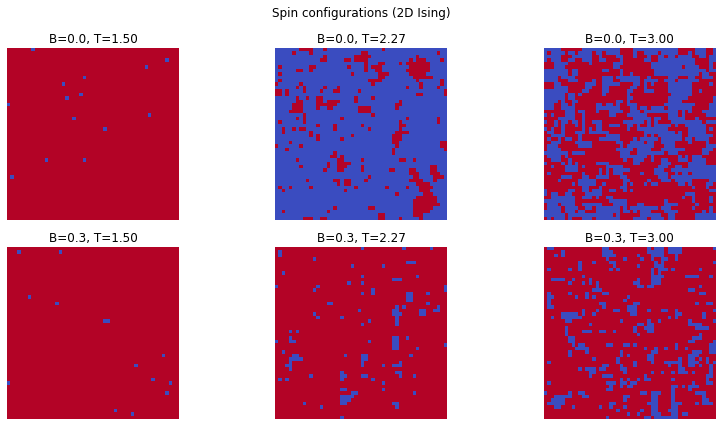

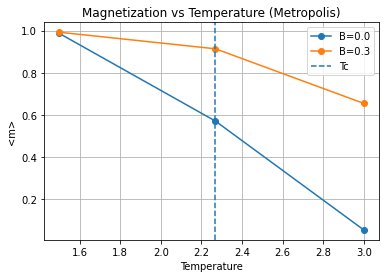

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# =============================
# 2D Ising Model (Metropolis)
# =============================

class Ising2D:
    def __init__(self, L=40, J=1.0, B=0.0, T=2.0):
        self.L = L
        self.N = L * L
        self.J = J
        self.B = B
        self.T = T
        self.beta = 1.0 / T
        self.spins = np.random.choice([-1, 1], size=(L, L))

    def energy(self):
        """Total energy (periodic boundary)"""
        s = self.spins
        E = -self.J * np.sum(s * np.roll(s, 1, axis=0))
        E += -self.J * np.sum(s * np.roll(s, 1, axis=1))
        E += -self.B * np.sum(s)
        return E

    def magnetization(self):
        return np.mean(self.spins)

    def metropolis_step(self):
        """One Monte Carlo sweep"""
        for _ in range(self.N):
            i = np.random.randint(0, self.L)
            j = np.random.randint(0, self.L)

            s = self.spins[i, j]
            neighbors = (
                self.spins[(i+1)%self.L, j] +
                self.spins[(i-1)%self.L, j] +
                self.spins[i, (j+1)%self.L] +
                self.spins[i, (j-1)%self.L]
            )

            dE = 2 * self.J * s * neighbors + 2 * self.B * s

            if dE < 0 or np.random.rand() < np.exp(-self.beta * dE):
                self.spins[i, j] *= -1

    def run(self, steps=2000, thermalization=500):
        mags = []
        energies = []

        for step in range(steps):
            self.metropolis_step()
            if step > thermalization:
                mags.append(self.magnetization())
                energies.append(self.energy() / self.N)

        return np.array(mags), np.array(energies)

# =============================
# Simulation setup
# =============================
L = 50
steps = 2500

Tc = 2.269

temps = [1.5, Tc, 3.0]  # below, near, above Tc
B_values = [0.0, 0.3]

configs = {}
avg_m = {}

for B in B_values:
    avg_m[B] = []
    for T in temps:
        model = Ising2D(L=L, J=1.0, B=B, T=T)
        mags, energies = model.run(steps=steps)
        configs[(B, T)] = model.spins.copy()
        avg_m[B].append(np.mean(np.abs(mags)))
        

# =============================
# Visualization 1: Spin configurations
# =============================
fig, axes = plt.subplots(len(B_values), len(temps), figsize=(12,6))
for i, B in enumerate(B_values):
    for j, T in enumerate(temps):
        ax = axes[i, j]
        im = ax.imshow(configs[(B, T)], cmap='coolwarm', vmin=-1, vmax=1)
        ax.set_title(f"B={B}, T={T:.2f}")
        ax.axis('off')

plt.suptitle("Spin configurations (2D Ising)")
plt.tight_layout()
plt.show()

# =============================
# Visualization 2: Magnetization vs Temperature
# =============================
plt.figure(figsize=(6,4))
for B in B_values:
    plt.plot(temps, avg_m[B], marker='o', label=f"B={B}")

plt.axvline(Tc, linestyle='--', label='Tc')
plt.xlabel("Temperature")
plt.ylabel("<m>")
plt.title("Magnetization vs Temperature (Metropolis)")
plt.legend()
plt.grid()
plt.show()


## Wolff Algorithm

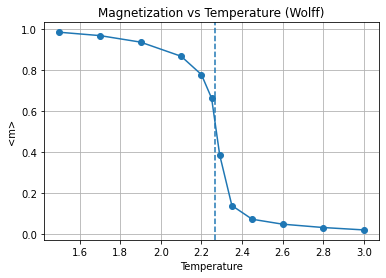

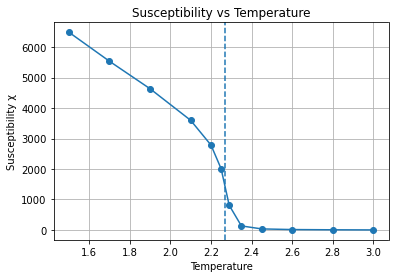

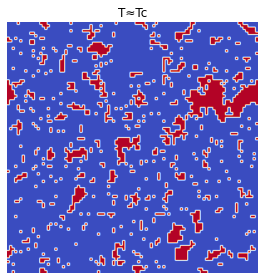

In [20]:
import numpy as np
import matplotlib.pyplot as plt

class Ising2D_Wolff:
    def __init__(self, L=40, J=1.0, T=2.0):
        self.L = L
        self.N = L * L
        self.J = J
        self.T = T
        self.beta = 1.0 / T
        self.spins = np.random.choice([-1, 1], size=(L, L))

    def magnetization(self):
        return np.mean(self.spins)

    def wolff_step(self):
        L = self.L
        beta = self.beta

        i = np.random.randint(0, L)
        j = np.random.randint(0, L)
        cluster_spin = self.spins[i, j]

        stack = [(i, j)]
        cluster = set([(i, j)])

        p_add = 1 - np.exp(-2 * beta * self.J)

        while stack:
            x, y = stack.pop()
            neighbors = [
                ((x+1)%L, y), ((x-1)%L, y),
                (x, (y+1)%L), (x, (y-1)%L)
            ]
            for nx, ny in neighbors:
                if (nx, ny) not in cluster and self.spins[nx, ny] == cluster_spin:
                    if np.random.rand() < p_add:
                        cluster.add((nx, ny))
                        stack.append((nx, ny))

        for (x, y) in cluster:
            self.spins[x, y] *= -1

    def run(self, steps=2000, thermalization=500):
        mags = []
        for step in range(steps):
            self.wolff_step()
            if step > thermalization:
                mags.append(self.magnetization())
        return np.array(mags)

L = 100
steps = 5000
Tc = 2.269

temps = np.array([1.5 , 1.7, 1.9, 2.1, 2.2, 2.25, 2.29, 2.35, 2.45, 2.6, 2.8, 3.0   ])

avg_m = []
susceptibility = []
configs = {}

for T in temps:
    model = Ising2D_Wolff(L=L, J=1.0, T=T)
    mags = model.run(steps=steps)

    avg_m.append(np.mean(np.abs(mags)))
    chi = (1.0 / T) * model.N * (np.mean(mags**2) - np.mean(mags)**2)
    susceptibility.append(chi)

    if abs(T - Tc) == min(abs(temps - Tc)):
        configs[T] = model.spins.copy()

plt.figure(figsize=(6,4))
plt.plot(temps, avg_m, marker='o')
plt.axvline(Tc, linestyle='--')
plt.xlabel("Temperature")
plt.ylabel("<m>")
plt.title("Magnetization vs Temperature (Wolff)")
plt.grid()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(temps, susceptibility, marker='o')
plt.axvline(Tc, linestyle='--')
plt.xlabel("Temperature")
plt.ylabel("Susceptibility χ")
plt.title("Susceptibility vs Temperature")
plt.grid()
plt.show()

fig, axes = plt.subplots(1, len(configs), figsize=(5,4))
if len(configs) == 1:
    axes = [axes]
for ax, (T, config) in zip(axes, configs.items()):
    ax.imshow(config, cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_title(f"T≈Tc")
    ax.axis('off')

plt.tight_layout()
plt.show()
